----

----

# Proyecto final Sprint 8

Nuestra misión para este análisis es probar la siguiente hipótesis: "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Para llegar al resultado empezaremos analizando los datos de la siguiente manera:

In [1]:
#Importamos las librerías necesarias para el proyecto y hacemos una exploración inicial de los data sets.

import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st 
from scipy.stats import levene
from scipy.stats import f as f_test

In [2]:
companytripsdf = pd.read_csv('/datasets/project_sql_result_01.csv')
dropofftripsdf = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
companytripsdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [4]:
companytripsdf.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [5]:
companytripsdf.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [6]:
dropofftripsdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [7]:
dropofftripsdf.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [8]:
dropofftripsdf.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [9]:
#Redondeo de número de viajes para trabajar con números enteros

dropofftripsdf = dropofftripsdf.round(0)
dropofftripsdf.info

<bound method DataFrame.info of    dropoff_location_name  average_trips
0                   Loop        10727.0
1            River North         9524.0
2          Streeterville         6665.0
3              West Loop         5164.0
4                 O'Hare         2547.0
..                   ...            ...
89       Mount Greenwood            3.0
90             Hegewisch            3.0
91              Burnside            2.0
92             East Side            2.0
93             Riverdale            2.0

[94 rows x 2 columns]>

Después de nuestra exploración inicial de los datos, procedemos a limpiar los datos buscando valores ausentes y duplicados.

In [10]:
companytripsdf.isnull().sum()

company_name    0
trips_amount    0
dtype: int64

In [11]:
dropofftripsdf.isnull().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

In [12]:
companytripsdf.duplicated().sum()

0

In [13]:
dropofftripsdf.duplicated().sum()

0

Empezaremos a segmentar nuestra información conforme a las ubicaciones más populares para los viajes.

In [14]:
top_10_n = dropofftripsdf.sort_values(by=['average_trips'], ascending = False).head(10)
top_10_n.head(10)

,dropoff_location_name,average_trips
0,Loop,10727.0
1,River North,9524.0
2,Streeterville,6665.0
3,West Loop,5164.0
4,O'Hare,2547.0
5,Lake View,2421.0
6,Grant Park,2069.0
7,Museum Campus,1510.0
8,Gold Coast,1364.0
9,Sheffield & DePaul,1260.0


In [15]:
top_rides = companytripsdf.sort_values(by=['trips_amount'], ascending = False).head(10)
top_rides.head(10)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


Para ayudarnos a visualizar mejor nuestra información, crearemos un gráfico.

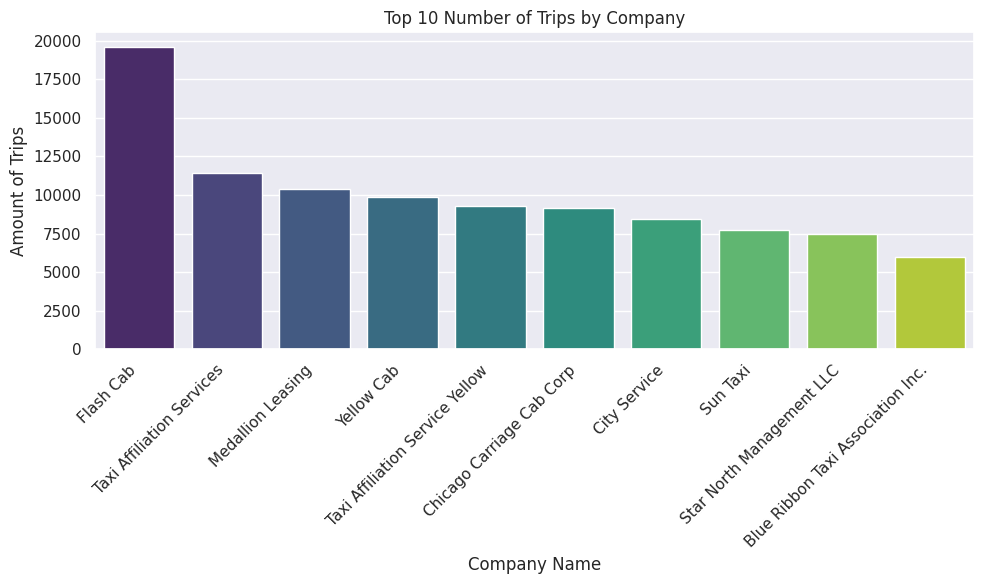

In [16]:
sns.set(rc={'figure.figsize':(10, 6)}) 

sns.barplot(data=top_rides, x='company_name', y='trips_amount', palette='viridis')\
    .set(title='Top 10 Number of Trips by Company', 
         xlabel='Company Name', 
         ylabel='Amount of Trips')

plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()

Basados en el gráfico anterior podemos decir que la compañía de taxis Flash Cab tuvo casi el doble de viajes que la siguiente empresa con más viajes entre el 15 y 16 de noviembre de 2017. La segunda en el ranking, Taxi Affiliation Services, mostró una disminución constante en número de viajes desde el puesto 2 hasta el puesto 10. En términos relativos, la empresa en el segundo lugar registró aproximadamente el doble de viajes que la compañía en el décimo lugar, con 1,142 viajes frente a 5,953.

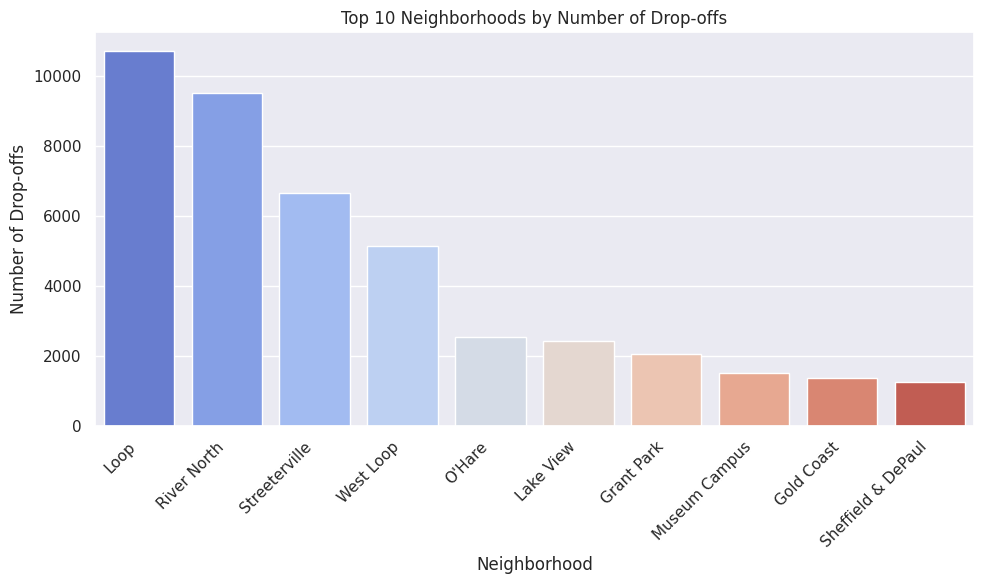

In [17]:
sns.set(rc={'figure.figsize':(10, 6)}) 
sns.barplot(data=top_10_n, x='dropoff_location_name', y='average_trips', palette='coolwarm')\
    .set(title='Top 10 Neighborhoods by Number of Drop-offs', 
         xlabel='Neighborhood', 
         ylabel='Number of Drop-offs')

plt.xticks(rotation=45, ha='right')

plt.tight_layout() 
plt.show()


En este segundo gráfico podemos ver que los dos barrios con más descensos de pasajeros en noviembre de 2017, Loop y River North, registraron un promedio cercano a 10,000 viajes. Después de ellos, hay una caída notable, con Streeterville en tercer lugar con 6,665 viajes y West Loop en cuarto con 5,164. Los seis barrios con menos descensos tuvieron menos de la mitad de la cantidad registrada en West Loop, lo que indica una distribución desigual, concentrándose en los primeros lugares.

Ahora analizaremos la información correspondiente al clima de Chicago pertinente a nuestra investigación, nuevamente empezaremos con una exploración inicial de nuestro data set y limpieza de duplicados y valores ausentes: 

In [18]:
weatherdf = pd.read_csv('/datasets/project_sql_result_07.csv')

In [19]:
weatherdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [20]:
weatherdf.describe()

,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


In [21]:
weatherdf.head(10)

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0
7,2017-11-18 11:00:00,Good,2280.0
8,2017-11-11 14:00:00,Good,2460.0
9,2017-11-11 12:00:00,Good,2040.0


In [22]:
weatherdf.isnull().sum()

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

In [23]:
weatherdf.duplicated().sum()

197

In [24]:
weatherdf['start_ts']= pd.to_datetime(weatherdf['start_ts'])
weatherdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


In [25]:
#Redondeo de segundos para trabajar con números enteros.

weatherdf_grouped = weatherdf.groupby('weather_conditions')['duration_seconds'].count()
weatherdf_grouped.head(10)

weather_conditions
Bad     180
Good    888
Name: duration_seconds, dtype: int64

Es hora de probar nuestra hipótesis: 

In [26]:
weatherdf_badw = weatherdf[weatherdf['weather_conditions'] == 'Bad']['duration_seconds']
weatherdf_goodw = weatherdf[weatherdf['weather_conditions'] == 'Good']['duration_seconds']

alpha = .05

results = st.ttest_ind(weatherdf_badw, weatherdf_goodw)

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

p-value:  6.517970327099473e-12
Rechazamos la hipótesis nula


# Conclusión

Dado el bajo valor de p, se rechaza la hipótesis nula, lo que indica que la duración promedio de los viajes sí cambia los sábados lluviosos. Es interesante notar que los viajes entre las dos ubicaciones analizadas duran más en estos días.

En Chicago, Flash Cab y TAS dominan el mercado de taxis, acumulando la mayoría de los viajes registrados. Los descensos de pasajeros tienden a concentrarse en las cuatro principales zonas de la ciudad: Loop, River North, Streeterville y West Loop, probablemente debido a la alta densidad poblacional en estas áreas céntricas. Además, durante noviembre, las condiciones climáticas influyen en la duración de los viajes en taxi, especialmente los sábados. El mal tiempo genera un aumento en el tiempo de traslado, ya que el tráfico se vuelve más lento y la cantidad de autos en circulación incrementa. Esto también puede estar relacionado con una disminución en el uso de medios de transporte alternativos como caminar, andar en bicicleta o utilizar el transporte público.




